### Task 1 Identify data quality issues in the dataset.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("Summer-Olympic-medals-1976-to-2008.csv",encoding="latin-1")

117 rows are NaN

In [71]:

print(df.isnull().sum())

City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64


117 rows are Duplicate

In [72]:

print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 117


after removing Duplicate values

In [73]:
df=df.drop_duplicates()
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


Incorrect Data Type. "Year" stored as "float64"

In [74]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15315 non-null  object 
 1   Year          15315 non-null  float64
 2   Sport         15315 non-null  object 
 3   Discipline    15315 non-null  object 
 4   Event         15315 non-null  object 
 5   Athlete       15315 non-null  object 
 6   Gender        15315 non-null  object 
 7   Country_Code  15315 non-null  object 
 8   Country       15315 non-null  object 
 9   Event_gender  15315 non-null  object 
 10  Medal         15315 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.4+ MB


fix data type (Year from float to int)

In [75]:
#the code work but because there are missing values it gives error

# df["Year"]=df["Year"].astype(int)
# df.info()

One athlete's `Gender` field says `Men` while the `Event_gender` says `W` (Women's event)

In [76]:

mis=df[(df["Gender"] == "Men") & (df["Event_gender"] == "W")]
print(f"Mismatch rows found: {len(mis)}")

Mismatch rows found: 1


Removing mismatched rows

In [77]:

df = df.drop(mis.index)
mis_after = df[(df["Gender"] == "Men") & (df["Event_gender"] == "W")]
print(f"Mismatch rows remaining: {len(mis_after)}")

Mismatch rows remaining: 0


Five countries carry a `*` character (e.g. `Puerto Rico*`, `Hong Kong*`). 
This asterisk is not part of the country name

In [78]:
df['Country'].unique()

array(['East Germany', 'Soviet Union', 'United States', 'Italy', 'Sweden',
       'Australia', 'Canada', 'West Germany', 'Netherlands',
       'United Kingdom', 'Hungary', 'Japan', 'Cuba', 'Poland', 'Bulgaria',
       'New Zealand', 'Belgium', 'Mexico', 'Jamaica', 'Finland',
       'Romania', 'Portugal', 'France', 'Brazil', 'Czechoslovakia',
       'Trinidad and Tobago', 'Yugoslavia', 'Venezuela', 'Puerto Rico*',
       'Korea, North', 'Bermuda*', 'Thailand', 'Spain', 'Denmark',
       'Switzerland', nan, 'Pakistan', 'Korea, South', 'Norway',
       'Austria', 'Iran', 'Mongolia', 'Ethiopia', 'Tanzania', 'Guyana',
       'Uganda', 'Ireland', 'India', 'Zimbabwe', 'Greece', 'Lebanon',
       'China', 'Nigeria', 'Kenya', 'Morocco', "Cote d'Ivoire", 'Algeria',
       'Turkey', 'Cameroon', 'Zambia', 'Dominican Republic', 'Iceland',
       'Egypt', 'Colombia', 'Peru', 'Taiwan', 'Syria', 'Costa Rica',
       'Suriname', 'Indonesia', 'Djibouti', 'Senegal', 'Philippines',
       'Netherlands Ant

Remove asterisk from country names

In [79]:

df["Country"] = df["Country"].str.strip().str.replace("*", "")
df['Country'].unique()

array(['East Germany', 'Soviet Union', 'United States', 'Italy', 'Sweden',
       'Australia', 'Canada', 'West Germany', 'Netherlands',
       'United Kingdom', 'Hungary', 'Japan', 'Cuba', 'Poland', 'Bulgaria',
       'New Zealand', 'Belgium', 'Mexico', 'Jamaica', 'Finland',
       'Romania', 'Portugal', 'France', 'Brazil', 'Czechoslovakia',
       'Trinidad and Tobago', 'Yugoslavia', 'Venezuela', 'Puerto Rico',
       'Korea, North', 'Bermuda', 'Thailand', 'Spain', 'Denmark',
       'Switzerland', nan, 'Pakistan', 'Korea, South', 'Norway',
       'Austria', 'Iran', 'Mongolia', 'Ethiopia', 'Tanzania', 'Guyana',
       'Uganda', 'Ireland', 'India', 'Zimbabwe', 'Greece', 'Lebanon',
       'China', 'Nigeria', 'Kenya', 'Morocco', "Cote d'Ivoire", 'Algeria',
       'Turkey', 'Cameroon', 'Zambia', 'Dominican Republic', 'Iceland',
       'Egypt', 'Colombia', 'Peru', 'Taiwan', 'Syria', 'Costa Rica',
       'Suriname', 'Indonesia', 'Djibouti', 'Senegal', 'Philippines',
       'Netherlands Antil

The dataset contains temporary political entities like 'Independent Olympic Participants' that are not actual countries

In [80]:

exclude_countries = [
    'Independent Olympic Participants (1992)',
    'Unified team']


Filter them out

In [81]:

df = df[~df['Country'].isin(exclude_countries)]

print(f"Original rows: {len(df)}")
print(f"After removing special cases: {len(df)}")
print(f"Removed: {len(df) - len(df)} rows")



Original rows: 15089
After removing special cases: 15089
Removed: 0 rows


In [82]:
df['Country'].unique()

array(['East Germany', 'Soviet Union', 'United States', 'Italy', 'Sweden',
       'Australia', 'Canada', 'West Germany', 'Netherlands',
       'United Kingdom', 'Hungary', 'Japan', 'Cuba', 'Poland', 'Bulgaria',
       'New Zealand', 'Belgium', 'Mexico', 'Jamaica', 'Finland',
       'Romania', 'Portugal', 'France', 'Brazil', 'Czechoslovakia',
       'Trinidad and Tobago', 'Yugoslavia', 'Venezuela', 'Puerto Rico',
       'Korea, North', 'Bermuda', 'Thailand', 'Spain', 'Denmark',
       'Switzerland', nan, 'Pakistan', 'Korea, South', 'Norway',
       'Austria', 'Iran', 'Mongolia', 'Ethiopia', 'Tanzania', 'Guyana',
       'Uganda', 'Ireland', 'India', 'Zimbabwe', 'Greece', 'Lebanon',
       'China', 'Nigeria', 'Kenya', 'Morocco', "Cote d'Ivoire", 'Algeria',
       'Turkey', 'Cameroon', 'Zambia', 'Dominican Republic', 'Iceland',
       'Egypt', 'Colombia', 'Peru', 'Taiwan', 'Syria', 'Costa Rica',
       'Suriname', 'Indonesia', 'Djibouti', 'Senegal', 'Philippines',
       'Netherlands Antil

### Task 2 Apply one missing value strategy and explain why.

Strategy: Drop Missing Rows because missing values are caused by data entry errors (skipped rows) and not by natural or random absence of data.

In [83]:
df=df.dropna()
print("MISSING VALUES AFTER")
print(df.isna().sum())

MISSING VALUES AFTER
City            0
Year            0
Sport           0
Discipline      0
Event           0
Athlete         0
Gender          0
Country_Code    0
Country         0
Event_gender    0
Medal           0
dtype: int64


In [84]:
df["Year"]=df["Year"].astype(int)

### Task 3 Detect and handle outliers using IQR.

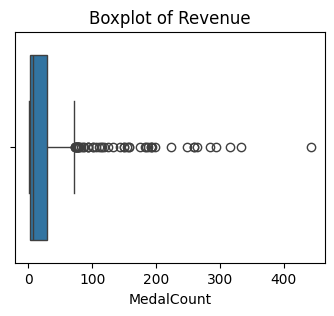

In [85]:
medals_by_country = df.groupby(['Year', 'Country']).size().reset_index(name='MedalCount')
plt.figure(figsize=(4,3))
sns.boxplot(x=medals_by_country['MedalCount'])
plt.title("Boxplot of Revenue")
plt.show()

In [86]:


Q1 = medals_by_country['MedalCount'].quantile(0.25)
Q3 = medals_by_country['MedalCount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = medals_by_country[(medals_by_country['MedalCount'] < lower) | (medals_by_country['MedalCount'] > upper)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(f"\nOutliers found: {len(outliers)}")
outliers.head(15)

Q1: 2.0, Q3: 30.0, IQR: 28.0
Lower bound: -40.0, Upper bound: 72.0

Outliers found: 52


,Year,Country,MedalCount
10,1976,East Germany,192
26,1976,Poland,73
30,1976,Soviet Union,285
37,1976,United States,155
39,1976,West Germany,75
45,1980,Bulgaria,94
49,1980,East Germany,260
67,1980,Soviet Union,442
83,1984,Canada,86
84,1984,China,76


In [87]:
medals_by_country_no_outliers = medals_by_country[(medals_by_country['MedalCount'] >= lower) & (medals_by_country['MedalCount'] <= upper)]

print("Original shape: ", medals_by_country.shape)
print("After removing outliers: ", medals_by_country_no_outliers.shape)
print(f"Removed {medals_by_country.shape[0] - medals_by_country_no_outliers.shape[0]} outlier rows")

Original shape:  (557, 3)
After removing outliers:  (505, 3)
Removed 52 outlier rows


### Capping Outliers (Percentile Method)

In [88]:
lower_cap = medals_by_country['MedalCount'].quantile(0.05)
upper_cap = medals_by_country['MedalCount'].quantile(0.95)

df_capped = medals_by_country.copy()
df_capped['MedalCount'] = df_capped['MedalCount'].clip(lower_cap, upper_cap)

### Task 4 Normalize numerical features using both Min-Max and Z-score.

- Min-Max Normalization

In [89]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = medals_by_country[[ 'MedalCount']].copy()

df_scaled[['MedalCount']] = scaler.fit_transform(df_scaled[['MedalCount']])

print("MIN-MAX SCALED: Medal Count per Country")
print(df_scaled.head())


MIN-MAX SCALED: Medal Count per Country
   MedalCount
0    0.052154
1    0.000000
2    0.018141
3    0.000000
4    0.004535


- Z-score

In [90]:
from sklearn.preprocessing import StandardScaler
medalsType_by_country = df.groupby(['Country', 'Medal']).size().unstack(fill_value=0)

scaler = StandardScaler()

# Copy only the columns you want
medals_standardized = medalsType_by_country[['Gold', 'Silver', 'Bronze']].copy()

# Apply scaling
medals_standardized[['Gold', 'Silver', 'Bronze']] = scaler.fit_transform(medals_standardized)

medals_standardized.head()

Medal,Gold,Silver,Bronze
Country,,,
Afghanistan,-0.380079,-0.499278,-0.522838
Algeria,-0.341679,-0.474062,-0.432498
Argentina,0.061516,-0.032781,0.367659
Armenia,-0.370479,-0.486670,-0.445403
Australia,1.693498,2.904889,3.490851


### Task 5 Apply PCA and interpret explained variance

In [91]:
pivot = df.groupby(['Country', 'Year']).size().unstack(fill_value=0)
pivot = pivot[pivot.sum(axis=1) >= 5]          # keep countries with ≥5 medals


scaler = StandardScaler()
df_standardized = pivot.copy()
df_standardized[pivot.columns] = scaler.fit_transform(pivot)
df_standardized.head()


Year,1976,1980,1984,1988,1992,1996,2000,2004,2008
Country,,,,,,,,,
Algeria,-0.369103,-0.288305,-0.341892,-0.408248,-0.430263,-0.479786,-0.441091,-0.530550,-0.468608
Argentina,-0.369103,-0.288305,-0.386521,-0.118575,-0.430263,-0.049965,-0.089557,0.520962,0.570051
Armenia,-0.369103,-0.288305,-0.386521,-0.408248,-0.485611,-0.505070,-0.534834,-0.530550,-0.383819
Australia,0.201535,-0.077870,0.729210,0.349358,1.091801,2.781797,3.730443,2.981947,2.647369
Austria,-0.345326,-0.200624,-0.319577,-0.385965,-0.319568,-0.479786,-0.464527,-0.351569,-0.447411


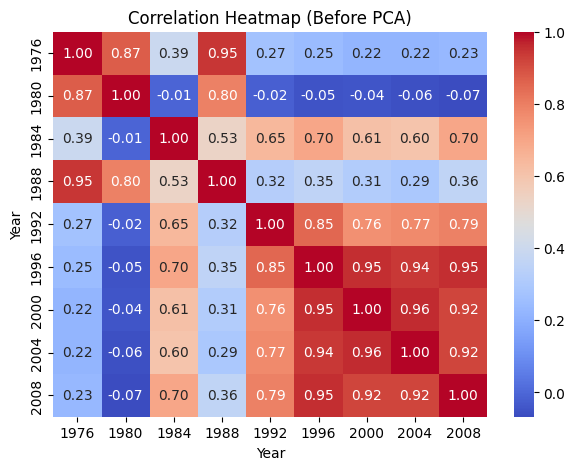

In [92]:

plt.figure(figsize=(7, 5))
sns.heatmap(df_standardized.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [93]:
from sklearn.decomposition import PCA
X = df_standardized[pivot.columns]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.60105874 0.28148692]


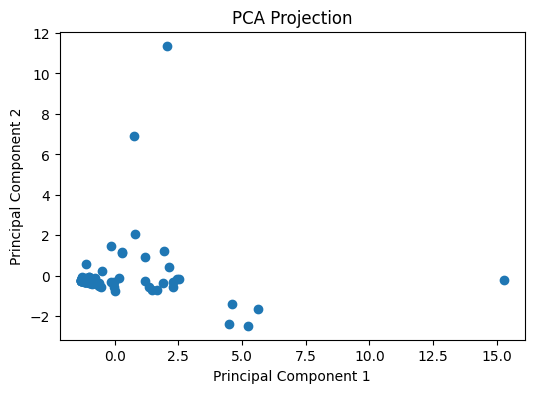

In [94]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()